In [1]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils import haversine, hp_mods, get_nn_lon_lat_index
    
# Filter out annoying warning.
import warnings


warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


In [2]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# sim = 'um_glm_n1280_GAL9_v2_hk26'
sim = 'um_glm_n2560_CoMA9_hk26'
sim = 'um_glm_n1280_CoMA9_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=4, time='PT1H').to_dask().pipe(hp_mods)

In [25]:
sim_obs = cat["IR_IMERG"]
# sim_cat(zoom=9).to_dask()
obs_ds = sim_obs(zoom=9).to_dask().pipe(egh.attach_coords).sel(time=slice("2020-01-21","2021-03-31"))

## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. Apply RefineOns to cut out parts which are just dry at the start or end of the identified onset period. This takes the filtered rainfall and requires that it exceeds its 10th percentile (as standard; can be changed) in order to be included as part of the onset.

The functions to calculate onset period for a single time series can be found in `onset_utils.py`. There is also a function to determine seasonality as in [Kahana et al. (2024)](https://www.frontiersin.org/journals/climate/articles/10.3389/fclim.2024.1419704/full), but ultimately this has not been used in analysis. `OnsetPeriod_toolbox.py` contains useful functions to facilitate onset calculations, including `RefineOns()`. 


In [3]:
for cell_ix in range(len(ds.pr.cell)):
    if cell_ix%10==0:
        print(cell_ix,(ds.sel(cell=cell_ix).lon.values,ds.sel(cell=cell_ix).lat.values))

0 (array(45.), array(2.38801546))
10 (array(36.5625), array(9.59406823))
20 (array(61.875), array(16.9577633))
30 (array(53.4375), array(24.62431835))
40 (array(28.125), array(16.9577633))
50 (array(42.1875), array(24.62431835))
60 (array(45.), array(32.7971683))
70 (array(70.3125), array(30.))
80 (array(78.75), array(32.7971683))
90 (array(70.3125), array(41.8103149))
100 (array(61.875), array(38.68218745))
110 (array(54.64285714), array(48.14120779))
120 (array(65.76923077), array(51.25580695))
130 (array(19.6875), array(24.62431835))
140 (array(22.5), array(32.7971683))
150 (array(36.5625), array(41.8103149))
160 (array(11.25), array(32.7971683))
170 (array(2.8125), array(41.8103149))
180 (array(24.23076923), array(51.25580695))
190 (array(4.5), array(60.43443884))
200 (array(38.07692308), array(51.25580695))
210 (array(58.5), array(60.43443884))
220 (array(70.71428571), array(69.42254649))
230 (array(28.125), array(66.44353569))
240 (array(45.), array(69.42254649))
250 (array(11.25

In [29]:
import OnsetPeriod_toolbox as optb
from onset_utils import onset_period_1d

fwin = 60
minlen = 30
# for cell_ix in [0, 1000, 1220, 2250, 3054]:
for cell_ix in [1461]:
    color = plt.cm.viridis(cell_ix / len(ds.pr.cell))
    pp = ds.pr.isel(cell=cell_ix).resample(time="1D").mean() * 3600

    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(
        pp,
        pp.time,
        refine=True,
        # precip_threshold=0.05,
        # intensity_threshold="60%",
    )

    fig, ax = plt.subplots()

    ax.plot(pp.time, pp, color=color, alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(fds[ix]) - 1),
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(lds[ix]) - 1),
            alpha=0.1,
            color=color,
        )
        for ix in range(len(fds))
        if int(fds[ix] == fds[ix])
    ]
    ax.plot(
        pp.time,
        flt,
        color=color,
    )
    ax.set_title(f"({pp.lon.data},{pp.lat.data})")

    ax2 = ax.twinx()

    ax2.plot(pp.time, grd, "--", color=color)

ClientResponseError: 503, message='Service Unavailable', url='http://hackathon-o.s3.jc.rl.ac.uk/sim-data/prod/v7/glm.n1280_CoMA9/um.PT1H.hp_z4.zarr/pr/6.0'

In [4]:
def constrain_healpix(ds, left, right, bottom, top):
    region_mask = (
        (ds.lon > left) & (ds.lon < right) & (ds.lat > bottom) & (ds.lat < top)
    )
    return ds.where(region_mask)

In [ ]:
chirps = xr.open_dataarray(
    "/home/users/franmorr/firstrains/OnsetPeriod/data/CHIRPS/CHIRPS_precip.day.total_1981-2025.025dg.aw.nc"
)

# chirps.sel(longitude=357.25,latitude=14.5,time=slice("2020-01-21","2021-03-31")).plot()
chirps.sel(longitude=76,latitude=9.5,time=slice("2020-01-21","2021-03-31")).plot()

In [ ]:
import OnsetPeriod_toolbox as optb
from onset_utils import onset_period_1d

fwin = 60
minlen = 30
# for cell_ix in [0, 1000, 1220, 2250, 3054]:
for cell_ix in [0]:
    color = plt.cm.viridis(0.6)
    pp = chirps.sel(longitude=76,latitude=9.5,time=slice("2020-01-21","2021-03-31")) / 24

    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(
        pp,
        pp.time,
        refine=True,
        # precip_threshold=0.05,
        # intensity_threshold="60%",
    )

    fig, ax = plt.subplots()

    ax.plot(pp.time, pp, color=color, alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(fds[ix]) - 1),
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(lds[ix]) - 1),
            alpha=0.1,
            color=color,
        )
        for ix in range(len(fds))
        if int(fds[ix] == fds[ix])
    ]
    ax.plot(
        pp.time,
        flt,
        color=color,
    )
    ax.set_title(f"CHIRPS @ ({pp.longitude.data},{pp.latitude.data})")

    ax2 = ax.twinx()

    ax2.plot(pp.time, grd, "--", color=color)

# Plot maps of onset data

Text(0.5, 0.98, 'precip_0p05 | zoom 7')

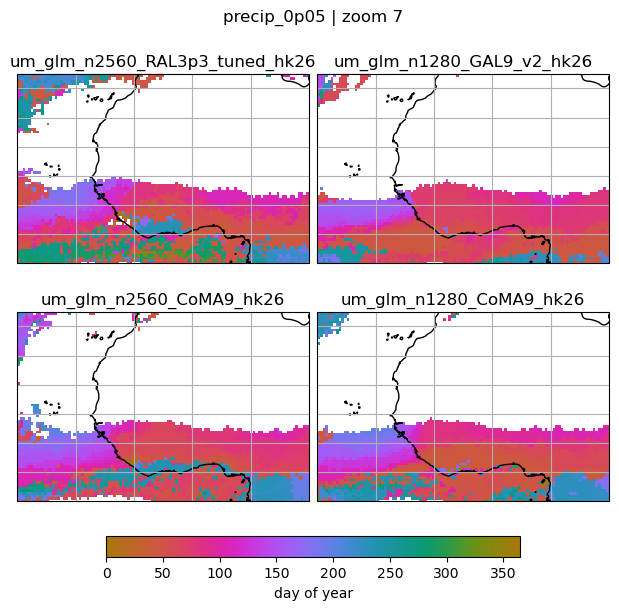

In [3]:




def plot_first_day(ax, sim, extent=None, period_ix=0, thresholds="nofilter"):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    da = (
        xr.open_dataset(f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc")
        .sel(period=period_ix)
        .first_day_of_period
    )
    m = da.plot(cmap=cmo.cm.phase, vmin=0, vmax=365, ax=ax, add_colorbar=False)
    ax.set_title(sim)
    ax.coastlines()
    ax.gridlines()
    return ax, m


# South America
left = -80
right = -30
bottom = -40
top = 10
figsize=(6,6)


# # South Africa
# left=10
# right=50
# bottom=-40
# top=0
# figsize=(6,6)


# West Africa
left=-30
right=20
bottom=0
top=30
# figsize=None


# India
# left = 60
# right = 100
# bottom = 0
# top = 40
# figsize=(6,6)


# # East Asia
# left=100
# right=140
# bottom=10
# top=50
# figsize=(6,6)

#Globe
# left=-180
# right=180
# bottom=-90
# top=90
# figsize=None

zoom = 7
thresholds="precip_0p05"

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_first_day(
    axes[0, 0],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[0, 1],
    "um_glm_n1280_GAL9_v2_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[1, 0],
    "um_glm_n2560_CoMA9_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[1, 1],
    "um_glm_n1280_CoMA9_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
fig.suptitle(f"{thresholds} | zoom {zoom}")

Text(0.5, 0.98, 'precip_0p01_intensity_60 | zoom 3')

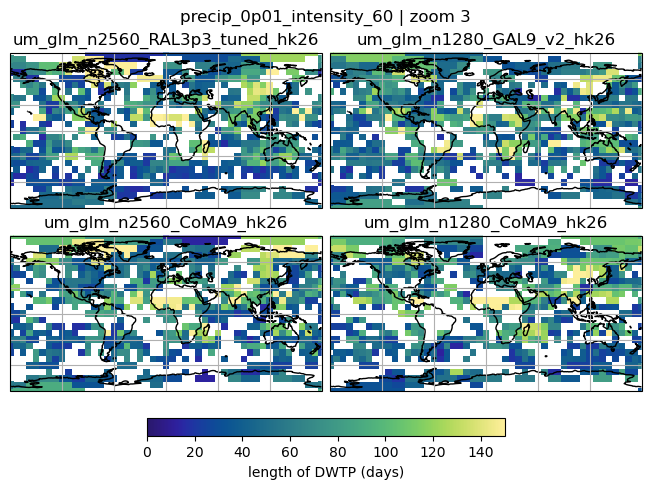

In [39]:


zoom = 3


def plot_length(ax, sim, extent=None, thresholds="nofilter"):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    ds = xr.open_dataset(f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc").sel(
        period=0
    )
    da = ds.last_day_of_period - ds.first_day_of_period
    m = da.plot(cmap=cmo.cm.haline, vmin=0, vmax=150, ax=ax, add_colorbar=False)
    ax.set_title(sim)
    ax.coastlines()
    ax.gridlines()
    return ax, m


# South America
left = -80
right = -30
bottom = -40
top = 10
figsize=(6,6)


# # South Africa
# left=10
# right=50
# bottom=-40
# top=0
# figsize=(6,6)


# # West Africa
left=-30
right=20
bottom=0
top=30

# India
# left = 60
# right = 100
# bottom = 0
# top = 40
# figsize=(6,6)


# # East Asia
# left=100
# right=140
# bottom=10
# top=50
# figsize=(6,6)

#Globe
left=-180
right=180
bottom=-90
top=90
figsize=None

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_length(
    axes[0, 0],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_length(
    axes[0, 1],
    "um_glm_n1280_GAL9_v2_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
# ax,m=plot_length(axes[0,1],"um_glm_n1280_GAL9_v2_hk26",)
ax, m = plot_length(
    axes[1, 0],
    "um_glm_n2560_CoMA9_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)
# ax,m=plot_length(axes[1,0],"um_glm_n2560_CoMA9_hk26",)
ax, m = plot_length(
    axes[1, 1],
    "um_glm_n1280_CoMA9_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="length of DWTP (days)",
)
plt.suptitle(f"{thresholds} | zoom {zoom}")